# Airbnb Text Mining Project
Clean pipeline: data → preprocessing → TF-IDF → sentiment labels → supervised learning

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from textblob import TextBlob


## Load dataset

In [4]:

url = "https://media.githubusercontent.com/media/ElvisCasco/Text_Mining_Project/refs/heads/main/reviews_translated.csv"

data = pd.read_csv(url)

print(data.shape)
data.head()


(1019270, 7)


,listing_id,id,date,reviewer_id,reviewer_name,comments,Reviews_Translation
0,703984,415003002495917725,2021-07-26,324403082,Gabriela,"Excelente lugar y buena ubicación, repetiría e...","Excellent place and good location, I would rep..."
1,703984,422225979748637708,2021-08-05,208472604,Abdoulaye,Very good host and always ready to help,Very good host and always ready to help
2,703984,428711187547685597,2021-08-14,75793287,Nikos,Excellent place to stay and great location. Re...,Excellent place to stay and great location. Re...
3,703984,435298891748897953,2021-08-23,207073569,Berta,"Easy and quick communication with the host, gr...","Easy and quick communication with the host, gr..."
4,703984,438894164765136324,2021-08-28,391402125,Ahmad,Beautiful apartment in a very great neighbourh...,Beautiful apartment in a very great neighbourh...


## Basic cleaning

In [5]:

data = data.dropna(subset=['Reviews_Translation'])
data = data.sample(100000, random_state=42)

print(data.shape)


(100000, 7)


## Text preprocessing

In [6]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

data['clean_text'] = data['Reviews_Translation'].apply(clean_text)

data['clean_text'].head()


526794    fantastic location and great apartment beds ar...
874881    apartment was a few minutes walk to las rambla...
668767    very great apartment  we felt like we were at ...
951854    we had a brilliant time staying at manus place...
587669    such a nice place to stay gorgeous high ceilin...
Name: clean_text, dtype: str

## TF-IDF Vectorization

In [7]:

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(data['clean_text'])

print(X.shape)


(100000, 5000)


## Generate sentiment labels

In [8]:

data['sentiment'] = data['Reviews_Translation'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

data['label'] = data['sentiment'].apply(lambda x: 1 if x > 0 else 0)

data['label'].value_counts()


label
1    88166
0    11834
Name: count, dtype: int64

In [9]:

y = data['label']

print(X.shape)
print(y.shape)


(100000, 5000)
(100000,)


## Train-test split

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Train model

In [11]:

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Evaluation

In [12]:

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.94795
[[ 2233   116]
 [  925 16726]]
              precision    recall  f1-score   support

           0       0.71      0.95      0.81      2349
           1       0.99      0.95      0.97     17651

    accuracy                           0.95     20000
   macro avg       0.85      0.95      0.89     20000
weighted avg       0.96      0.95      0.95     20000



## Most important words

In [19]:

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = coefficients.argsort()[-20:]
top_negative = coefficients.argsort()[:20]

print("Top positive words:")
print([feature_names[i] for i in top_positive])
print([coefficients[i] for i in top_positive])

print("\nTop negative words:")
print([feature_names[i] for i in top_negative])
print([coefficients[i] for i in top_negative])




Top positive words:
['fantastic', 'better', 'attentive', 'kind', 'ideal', 'pleasant', 'lovely', 'easy', 'amazing', 'wonderful', 'friendly', 'perfect', 'beautiful', 'comfortable', 'super', 'good', 'excellent', 'clean', 'nice', 'great']
[np.float64(6.566341266309122), np.float64(6.723085450336509), np.float64(6.812086666942048), np.float64(6.8939253551484505), np.float64(6.9522047737913715), np.float64(7.429082731303716), np.float64(7.473759485800134), np.float64(7.926875070268057), np.float64(8.096340611226477), np.float64(8.723066155713681), np.float64(8.90111293292327), np.float64(9.793273531692233), np.float64(10.230655203977056), np.float64(10.740185848159443), np.float64(10.790060627335397), np.float64(11.37535593674406), np.float64(11.937224982291626), np.float64(12.166482249829642), np.float64(12.937838718017886), np.float64(15.613771124345366)]

Top negative words:
['dirty', 'bad', 'cold', 'disappointing', 'terrible', 'disappointed', 'worst', 'impossible', 'uncomfortable', 'anno

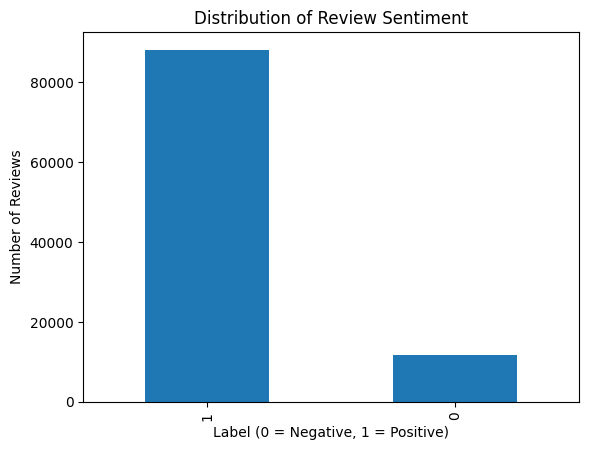

In [20]:
import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')

plt.title("Distribution of Review Sentiment")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")

plt.show()

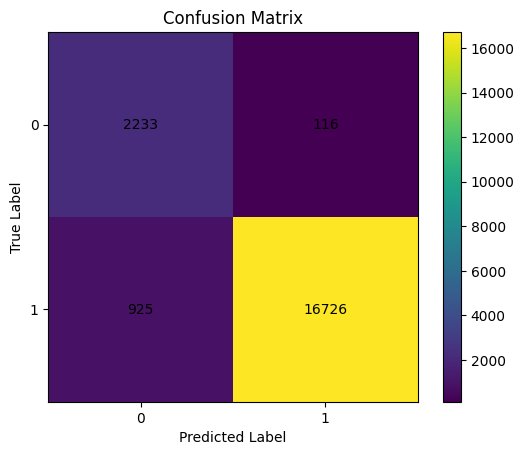

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0,1])
plt.yticks([0,1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

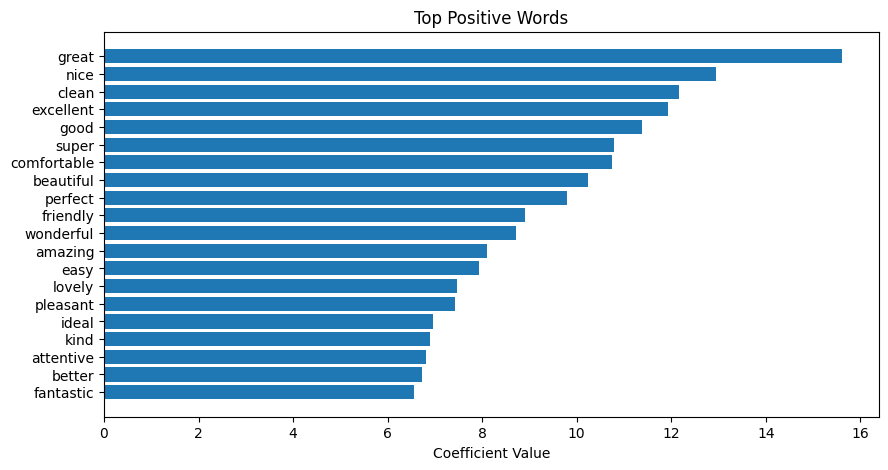

In [23]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_positive = np.argsort(coefficients)[-20:]
top_negative = np.argsort(coefficients)[:20]

positive_words = [feature_names[i] for i in top_positive]
negative_words = [feature_names[i] for i in top_negative]

positive_scores = coefficients[top_positive]
negative_scores = coefficients[top_negative]

plt.figure(figsize=(10,5))
plt.barh(positive_words, positive_scores)

plt.title("Top Positive Words")
plt.xlabel("Coefficient Value")

plt.show()

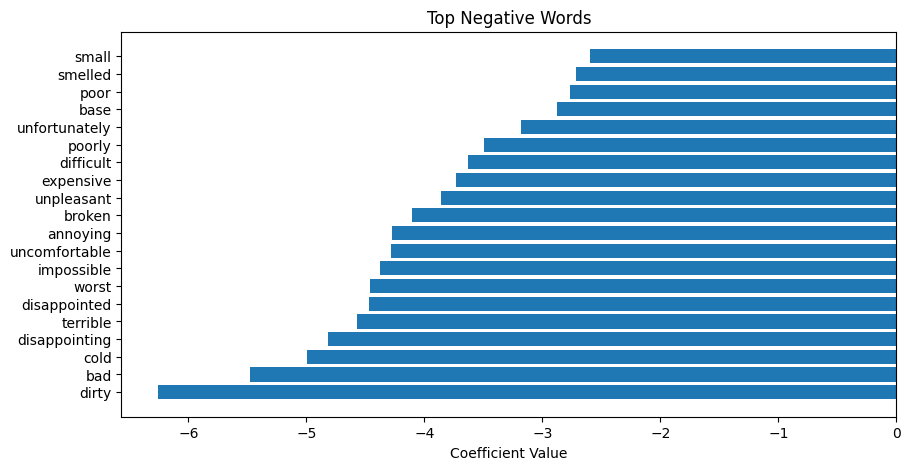

In [25]:
plt.figure(figsize=(10,5))
plt.barh(negative_words, negative_scores)

plt.title("Top Negative Words")
plt.xlabel("Coefficient Value")

plt.show()

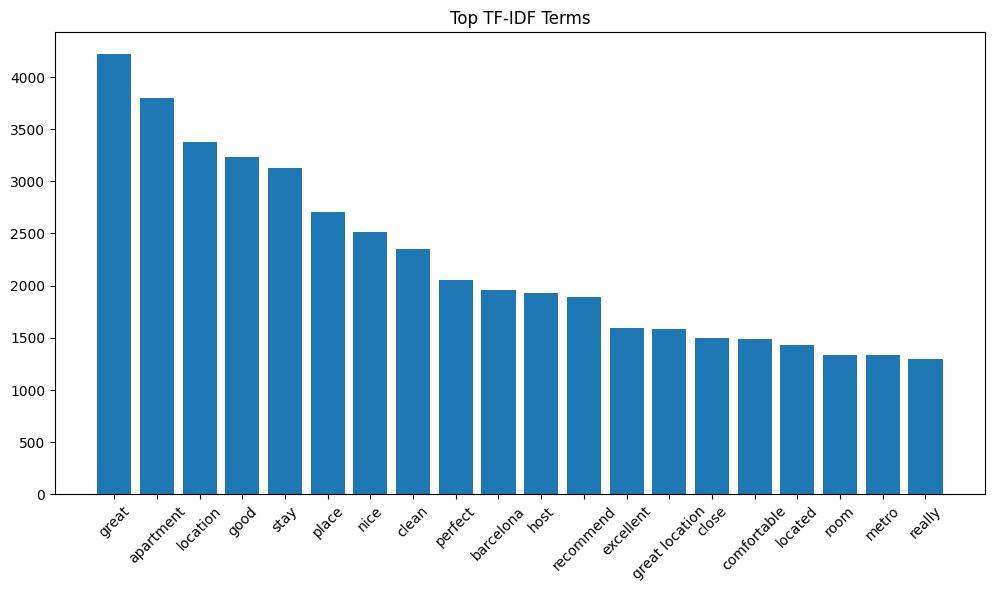

In [26]:
tfidf_scores = np.asarray(X.sum(axis=0)).ravel()

terms = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame({
    'term': terms,
    'score': tfidf_scores
})

df_tfidf = df_tfidf.sort_values(by='score', ascending=False).head(20)

plt.figure(figsize=(12,6))
plt.bar(df_tfidf['term'], df_tfidf['score'])

plt.xticks(rotation=45)
plt.title("Top TF-IDF Terms")

plt.show()

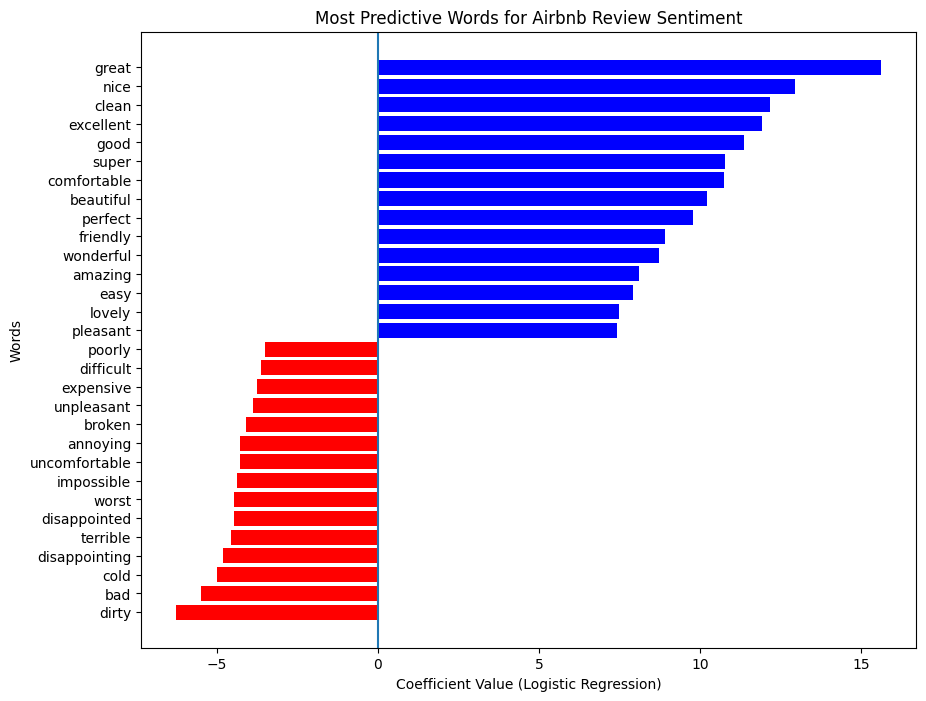

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener coeficientes y palabras
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top palabras
top_n = 15

top_positive_idx = np.argsort(coefficients)[-top_n:]
top_negative_idx = np.argsort(coefficients)[:top_n]

# Combinar
top_words_idx = np.concatenate([top_negative_idx, top_positive_idx])
top_words = [feature_names[i] for i in top_words_idx]
top_coefficients = coefficients[top_words_idx]

# Colores: rojo = negativo, azul = positivo
colors = ['red' if c < 0 else 'blue' for c in top_coefficients]

# Plot
plt.figure(figsize=(10,8))
plt.barh(top_words, top_coefficients, color=colors)

plt.title("Most Predictive Words for Airbnb Review Sentiment")
plt.xlabel("Coefficient Value (Logistic Regression)")
plt.ylabel("Words")

plt.axvline(0)  # línea en 0 para separar positivo/negativo

plt.show()